## Importing the Modules

In [29]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader


## Loading the data, pre-processing and transforming images to Tensor

In [12]:
train_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((75, 75)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=20),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

# Val and Test — clean, NO augmentation
eval_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((75, 75)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

train_data = datasets.ImageFolder(root='dataset/train', transform=train_transform)
test_data  = datasets.ImageFolder(root='dataset/test',  transform=eval_transform)  #
val_data   = datasets.ImageFolder(root='dataset/val',   transform=eval_transform)  #
train_loader = DataLoader(train_data, batch_size=64, shuffle=True, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_data, batch_size=64, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_data, batch_size=64, shuffle=False, num_workers=2, pin_memory=True)

## Defining the architecture of CNN

In [19]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class ConvolutionalNetwork(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1 = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.Conv2d(32,32,3,padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Dropout2d(0.10)
        )

        self.conv2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64,64,3,padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Dropout2d(0.15)
        )

        self.conv3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Conv2d(128,128,3,padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Dropout2d(0.20)
        )

        self.conv4 = nn.Sequential(
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.Conv2d(256,256,3,padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True)
        )

        self.global_pool = nn.AdaptiveAvgPool2d((1, 1))

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(128, 7)
        )

        self._initialize_weights()

    def _initialize_weights(self):
        for layer in self.modules():
            if isinstance(layer, nn.Conv2d):
                nn.init.kaiming_normal_(layer.weight, mode='fan_out', nonlinearity='relu')
                if layer.bias is not None:
                    nn.init.zeros_(layer.bias)
            elif isinstance(layer, nn.BatchNorm2d):
                nn.init.ones_(layer.weight)
                nn.init.zeros_(layer.bias)
            elif isinstance(layer, nn.Linear):
                nn.init.xavier_normal_(layer.weight)
                nn.init.zeros_(layer.bias)

    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        x = self.conv4(x)
        x = self.global_pool(x)
        x = self.classifier(x)
        return x

## Function for Training

In [20]:
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for X, y in loader:
        X = X.to(device)
        y = y.to(device)

        optimizer.zero_grad()
        logits = model(X)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        bs = y.size(0)
        running_loss += loss.item() * bs
        preds = logits.argmax(dim=1)
        correct += (preds == y).sum().item()
        total += bs

    return running_loss / total, 100.0 * correct / total


@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    for X, y in loader:
        X = X.to(device)
        y = y.to(device)

        logits = model(X)
        loss = criterion(logits, y)

        bs = y.size(0)
        running_loss += loss.item() * bs
        preds = logits.argmax(dim=1)
        correct += (preds == y).sum().item()
        total += bs

    return running_loss / total, 100.0 * correct / total

## Creating an Instantace

In [21]:
torch.manual_seed(41)
model = ConvolutionalNetwork().to(device)
model
print(torch.cuda.is_available())
print(device)
print(next(model.parameters()).device)

True
cuda
cuda:0


## Defining a Loss Function, Optimizer and a Scheduler

In [22]:
criterion = nn.CrossEntropyLoss(label_smoothing=0.05)

optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=3
)

## Training the data

In [23]:
epochs = 50
best_val_acc = 0.0
best_state = None

train_losses = []
val_losses = []
train_accs = []
val_accs = []

for epoch in range(epochs):
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion)
    val_loss, val_acc = evaluate(model, val_loader, criterion)

    scheduler.step(val_loss)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    print(f"Epoch {epoch+1:02d}/{epochs}")
    print(f"  Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")
    print(f"  Val   Loss: {val_loss:.4f} | Val   Acc: {val_acc:.2f}%")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

print(f"\nBest validation accuracy: {best_val_acc:.2f}%")

if best_state is not None:
    model.load_state_dict(best_state)

Epoch 01/50
  Train Loss: 1.8877 | Train Acc: 22.22%
  Val   Loss: 1.8315 | Val   Acc: 26.23%
Epoch 02/50
  Train Loss: 1.8310 | Train Acc: 25.48%
  Val   Loss: 1.7712 | Val   Acc: 29.50%
Epoch 03/50
  Train Loss: 1.7589 | Train Acc: 31.24%
  Val   Loss: 1.6375 | Val   Acc: 38.79%
Epoch 04/50
  Train Loss: 1.6401 | Train Acc: 38.67%
  Val   Loss: 1.4447 | Val   Acc: 48.16%
Epoch 05/50
  Train Loss: 1.5003 | Train Acc: 45.70%
  Val   Loss: 1.3188 | Val   Acc: 54.22%
Epoch 06/50
  Train Loss: 1.3878 | Train Acc: 51.05%
  Val   Loss: 1.2007 | Val   Acc: 58.40%
Epoch 07/50
  Train Loss: 1.2963 | Train Acc: 55.34%
  Val   Loss: 1.1036 | Val   Acc: 64.11%
Epoch 08/50
  Train Loss: 1.2348 | Train Acc: 58.37%
  Val   Loss: 1.0633 | Val   Acc: 65.49%
Epoch 09/50
  Train Loss: 1.1865 | Train Acc: 60.77%
  Val   Loss: 1.0059 | Val   Acc: 68.59%
Epoch 10/50
  Train Loss: 1.1485 | Train Acc: 62.67%
  Val   Loss: 0.9937 | Val   Acc: 67.98%
Epoch 11/50
  Train Loss: 1.1123 | Train Acc: 64.24%
  Val  

## Testing the Data

In [24]:
model.eval()

test_correct = 0
test_loss = 0

emotion_labels = [
    'Angry','Disgust','Fear',
    'Happy','Neutral','Sad','Surprise'
]

class_correct = [0]*7
class_total = [0]*7

with torch.no_grad():

    for X_test, y_test in test_loader:

        X_test = X_test.to(device)
        y_test = y_test.to(device)

        outputs = model(X_test)

        loss = criterion(outputs, y_test)
        test_loss += loss.item() * X_test.size(0)

        predicted = outputs.argmax(dim=1)

        test_correct += (predicted == y_test).sum().item()

        for label, pred in zip(y_test, predicted):
            class_total[label.item()] += 1

            if label == pred:
                class_correct[label.item()] += 1


test_loss /= len(test_loader.dataset)
test_acc = 100 * test_correct / len(test_loader.dataset)

print(f"\n{'='*40}")
print(f"Test Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_acc:.2f}%")
print(f"{'='*40}")

print("\nPer Class Accuracy")
print("-"*35)

for i in range(7):
    acc = 100 * class_correct[i] / class_total[i]
    print(f"{emotion_labels[i]:<10}: {acc:.2f}% ({class_correct[i]}/{class_total[i]})")


Test Loss     : 0.4967
Test Accuracy : 92.00%

Per Class Accuracy
-----------------------------------
Angry     : 97.65% (581/595)
Disgust   : 92.94% (553/595)
Fear      : 99.83% (594/595)
Happy     : 89.75% (534/595)
Neutral   : 78.66% (468/595)
Sad       : 88.74% (528/595)
Surprise  : 96.47% (574/595)


## Saving the Best Model

In [26]:
if best_state is not None:
    torch.save(best_state, "best_emotion_model.pth")
    print(f"Best model saved with validation accuracy = {best_val_acc:.2f}%")

Best model saved with validation accuracy = 92.11%


              precision    recall  f1-score   support

       Angry     0.9683    0.9765    0.9724       595
     Disgust     0.8876    0.9294    0.9080       595
        Fear     0.9738    0.9983    0.9859       595
       Happy     0.9144    0.8975    0.9059       595
     Neutral     0.8635    0.7866    0.8232       595
         Sad     0.8742    0.8874    0.8807       595
    Surprise     0.9535    0.9647    0.9591       595

    accuracy                         0.9200      4165
   macro avg     0.9193    0.9200    0.9193      4165
weighted avg     0.9193    0.9200    0.9193      4165



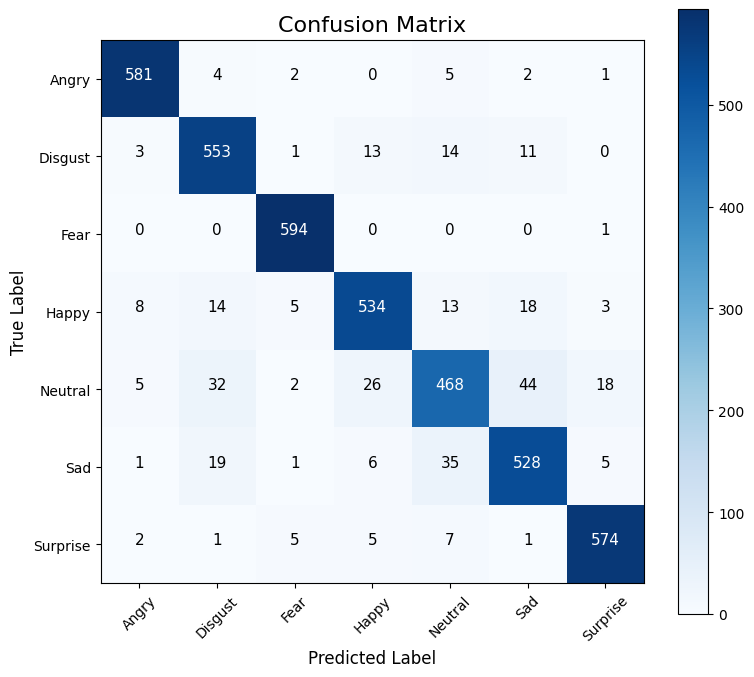

In [31]:
all_preds = []
all_labels = []

with torch.no_grad():
    for X, y in test_loader:

        X = X.to(device)
        y = y.to(device)

        outputs = model(X)
        preds = outputs.argmax(1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y.cpu().numpy())

print(classification_report(
    all_labels,
    all_preds,
    target_names=emotion_labels,
    digits=4
))

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8,7))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title("Confusion Matrix", fontsize=16)
plt.colorbar()

tick_marks = np.arange(len(emotion_labels))
plt.xticks(tick_marks, emotion_labels, rotation=45)
plt.yticks(tick_marks, emotion_labels)

# Write values inside each cell
thresh = cm.max() / 2

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(
            j, i,
            str(cm[i, j]),
            horizontalalignment="center",
            color="white" if cm[i, j] > thresh else "black",
            fontsize=11
        )

plt.ylabel("True Label", fontsize=12)
plt.xlabel("Predicted Label", fontsize=12)
plt.tight_layout()